In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.rcParams["figure.figsize"] = (20, 5)

import sys
sys.path.append('..')  

from src.dataloader import ChallengeDataLoader

In [3]:
train_df = ChallengeDataLoader.load_train_df()
test_df = ChallengeDataLoader.load_X_test()

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 527073 entries, 0 to 527072
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   TS                     527073 non-null  object 
 1   ALLOCATION             527073 non-null  object 
 2   RET_20                 527015 non-null  float64
 3   RET_19                 527023 non-null  float64
 4   RET_18                 527031 non-null  float64
 5   RET_17                 527039 non-null  float64
 6   RET_16                 527047 non-null  float64
 7   RET_15                 527055 non-null  float64
 8   RET_14                 527060 non-null  float64
 9   RET_13                 527064 non-null  float64
 10  RET_12                 527067 non-null  float64
 11  RET_11                 527069 non-null  float64
 12  RET_10                 527071 non-null  float64
 13  RET_9                  527073 non-null  float64
 14  RET_8                  527073 non-null  f

In [5]:
train_df.head()

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target,target_binarized
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1,0.009210,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4,0.000405,1
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1,0.005967,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2,-0.000542,0
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4,-0.002579,0


c.70% de nan dans SIGNED_VOLUME_1

<Axes: >

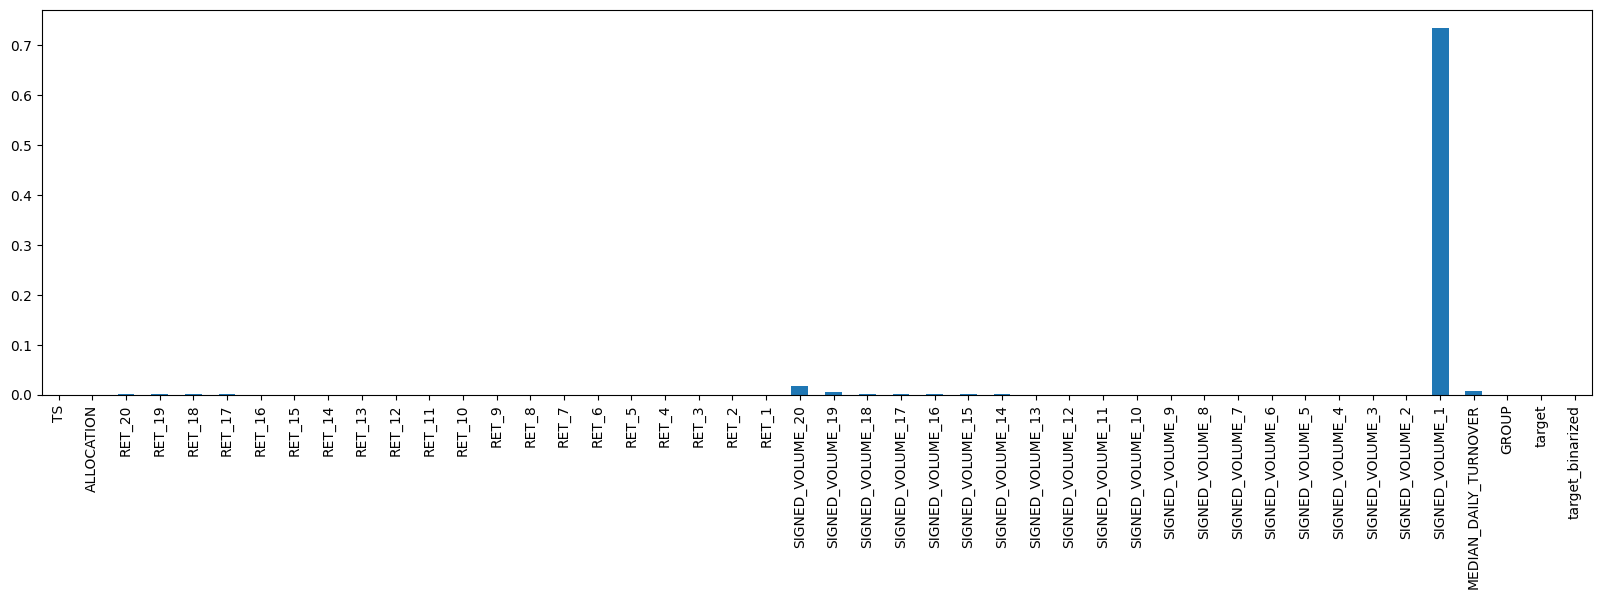

In [11]:
train_df.isna().mean().plot(kind="bar")

c'est stable dans le train / test et entre allocations 

<Axes: xlabel='ALLOCATION'>

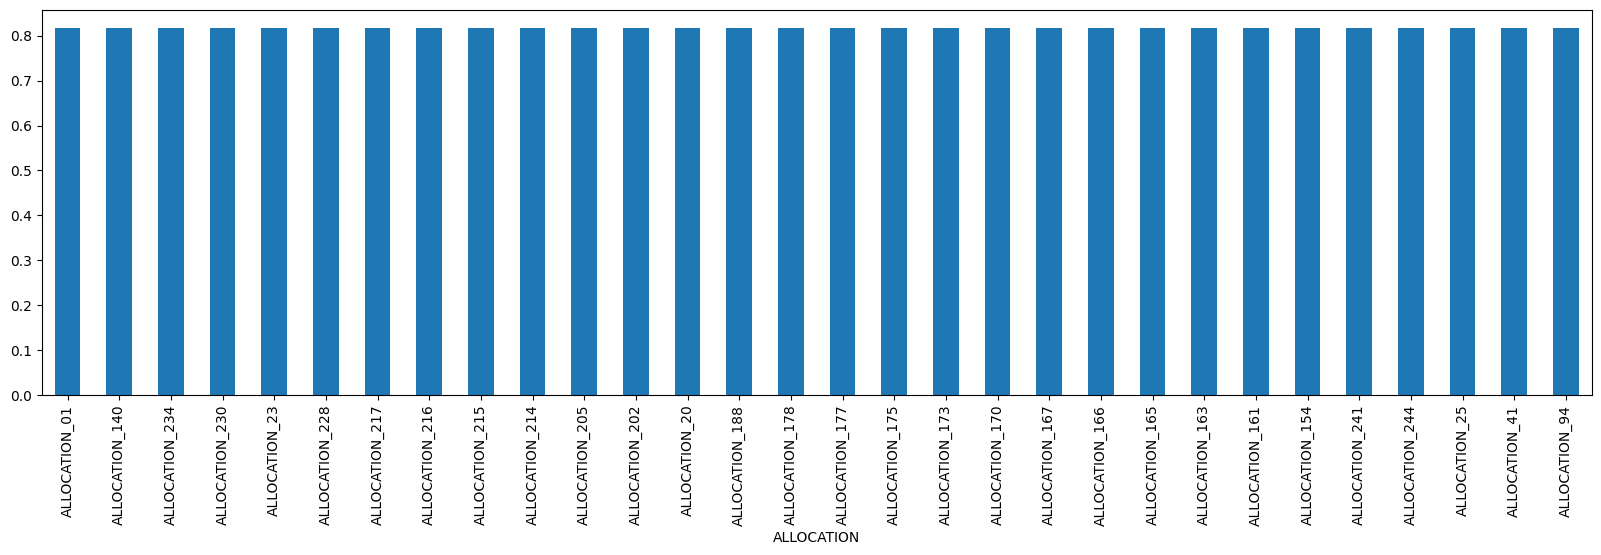

In [7]:
train_df.groupby("ALLOCATION")["SIGNED_VOLUME_1"].apply(lambda group : group.isna().mean()).sort_values(ascending=False).head(30).plot(kind="bar")

<Axes: >

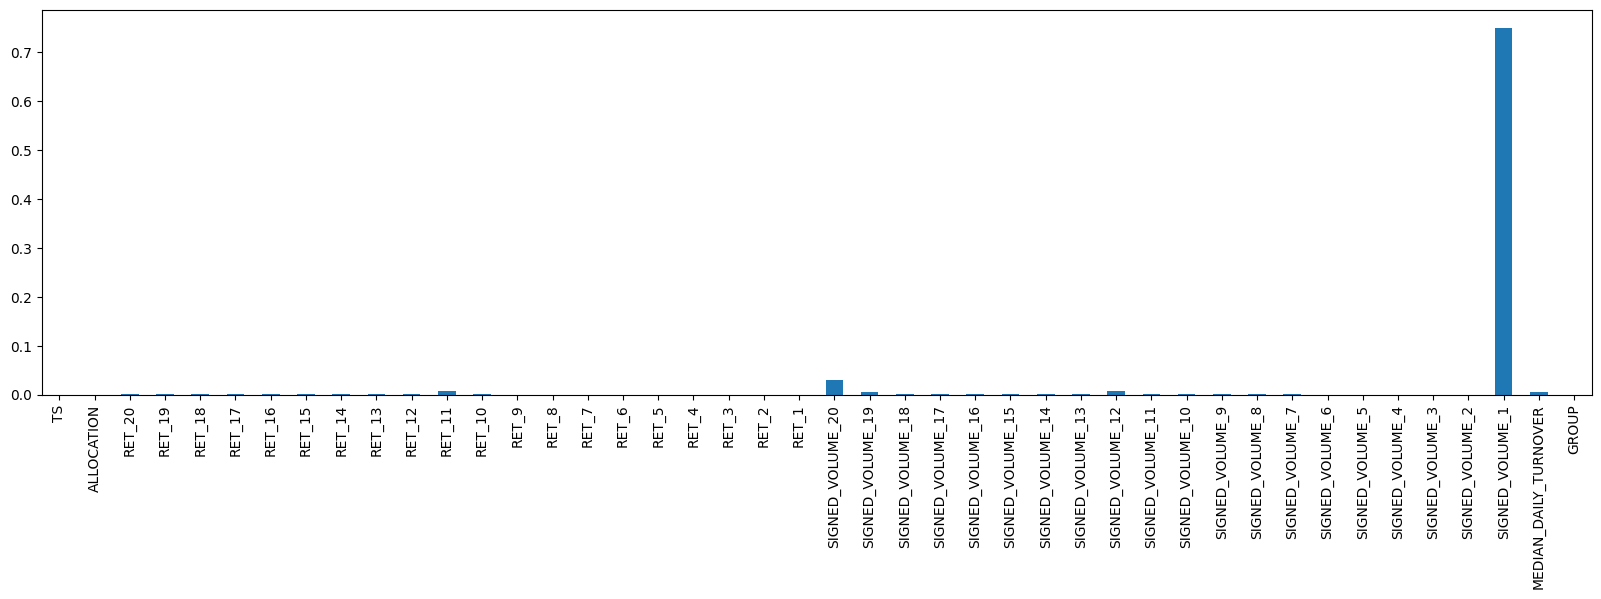

In [4]:
test_df.isna().mean().plot(kind="bar")

In [28]:
print(
    "TRAIN:\n"
    f"  unique dates: {train_df.TS.nunique()}\n"
    f"  unique allocations: {train_df.ALLOCATION.nunique()}\n"
    f"  shape: {train_df.shape}\n"
    "\nTEST:\n"
    f"  unique dates: {test_df.TS.nunique()}\n"
    f"  unique allocations: {test_df.ALLOCATION.nunique()}\n"
    f"  shape: {test_df.shape}"
)

TRAIN:
  unique dates: 2522
  unique allocations: 278
  shape: (527073, 46)

TEST:
  unique dates: 120
  unique allocations: 278
  shape: (31870, 44)


<Axes: xlabel='TS'>

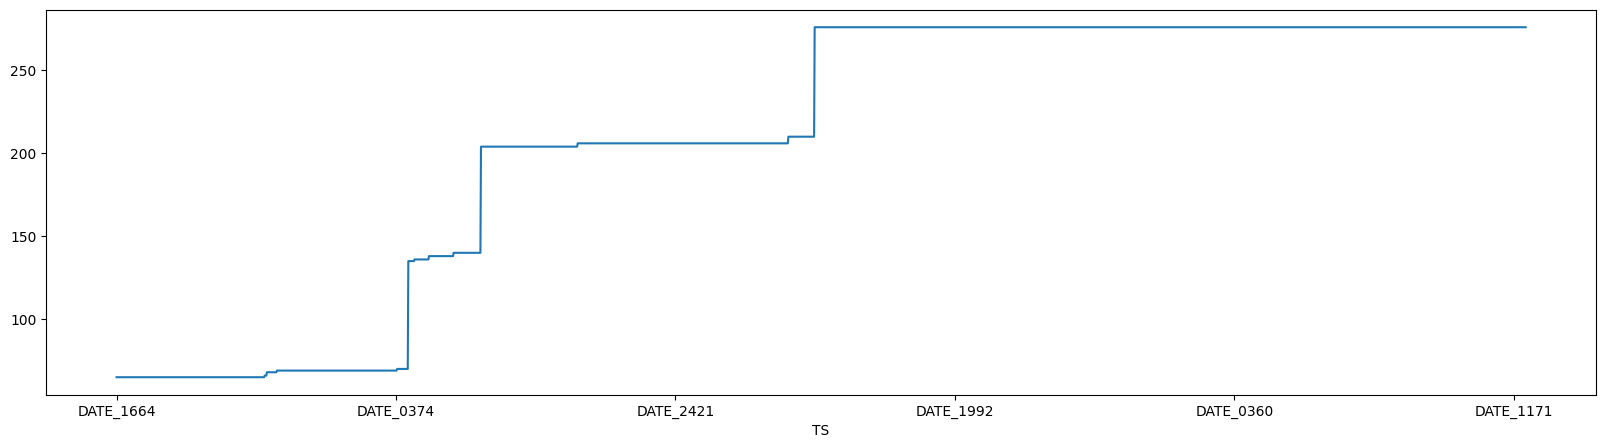

In [31]:
train_df.TS.value_counts(ascending=True).plot()

les effects allocation peuvent etre surappris a cause de la repartition 

<Axes: xlabel='ALLOCATION'>

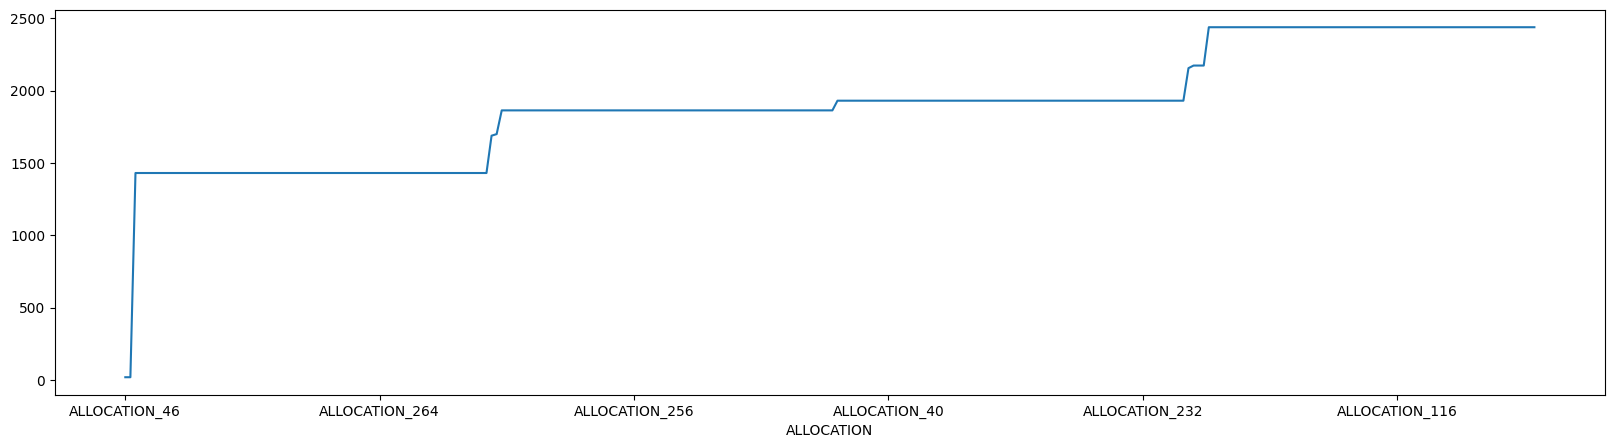

In [30]:
train_df.ALLOCATION.value_counts(ascending=True).plot()

In [33]:
train_df.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP',
       'target', 'target_binarized'],
      dtype='object')

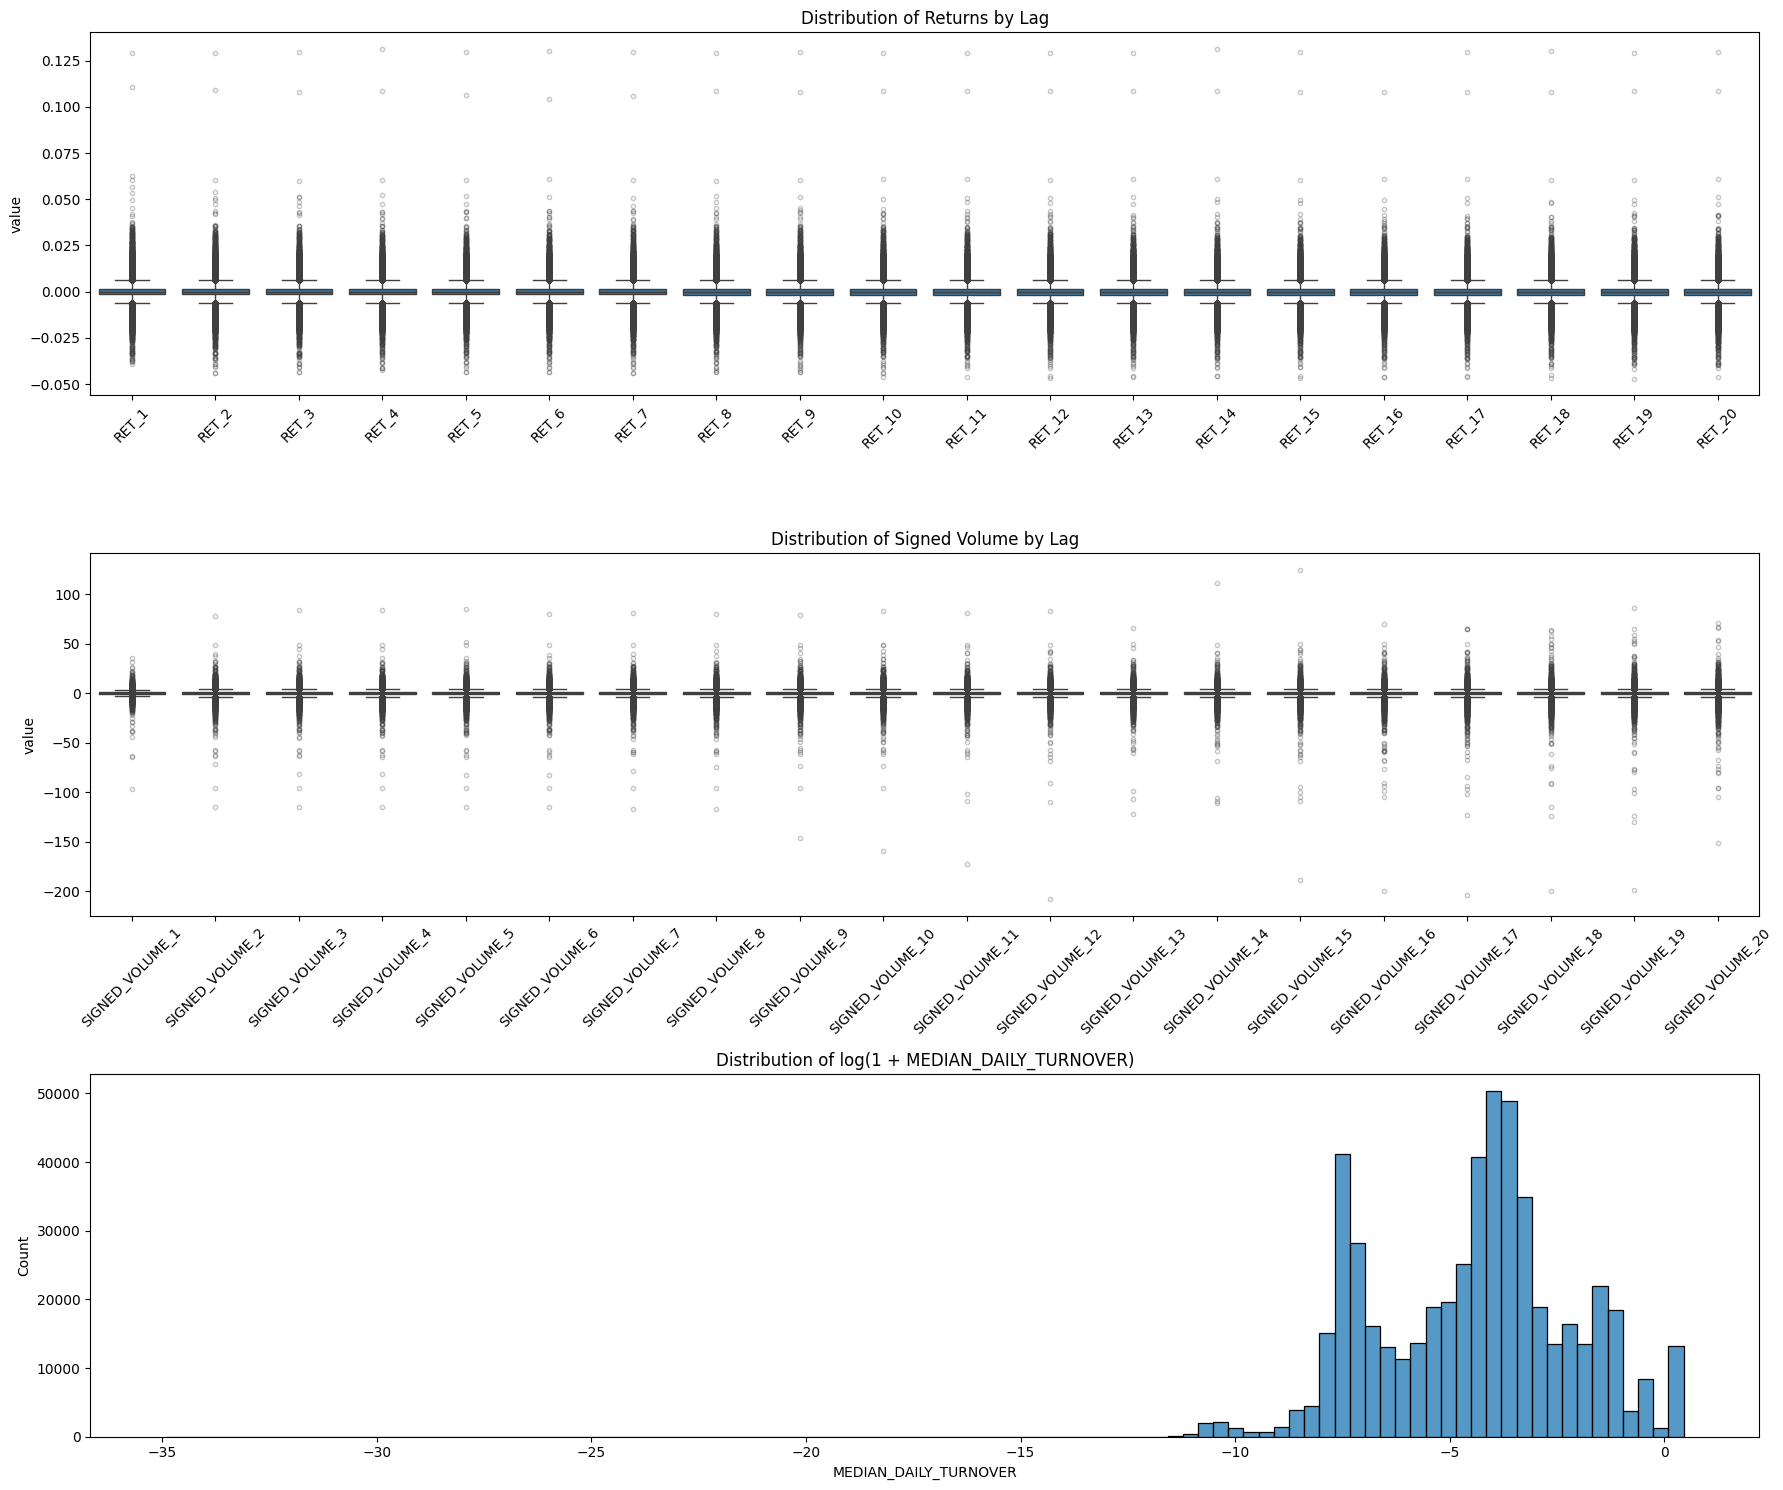

In [ ]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

train_df[ret_cols].melt(var_name="lag", value_name="value").pipe( # long df pour seaborn 
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[0], 
                          order=ret_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[0].set_title("Distribution of Returns by Lag")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# Signed Volume
train_df[vol_cols].melt(var_name="lag", value_name="value").pipe(
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[1],
                          order=vol_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[1].set_title("Distribution of Signed Volume by Lag")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

# Turnover
sns.histplot(
    train_df["MEDIAN_DAILY_TURNOVER"].apply(np.log), 
    bins=100, ax=axes[2]
)
axes[2].set_title("Distribution of log(1 + MEDIAN_DAILY_TURNOVER)")

plt.tight_layout()
plt.show()

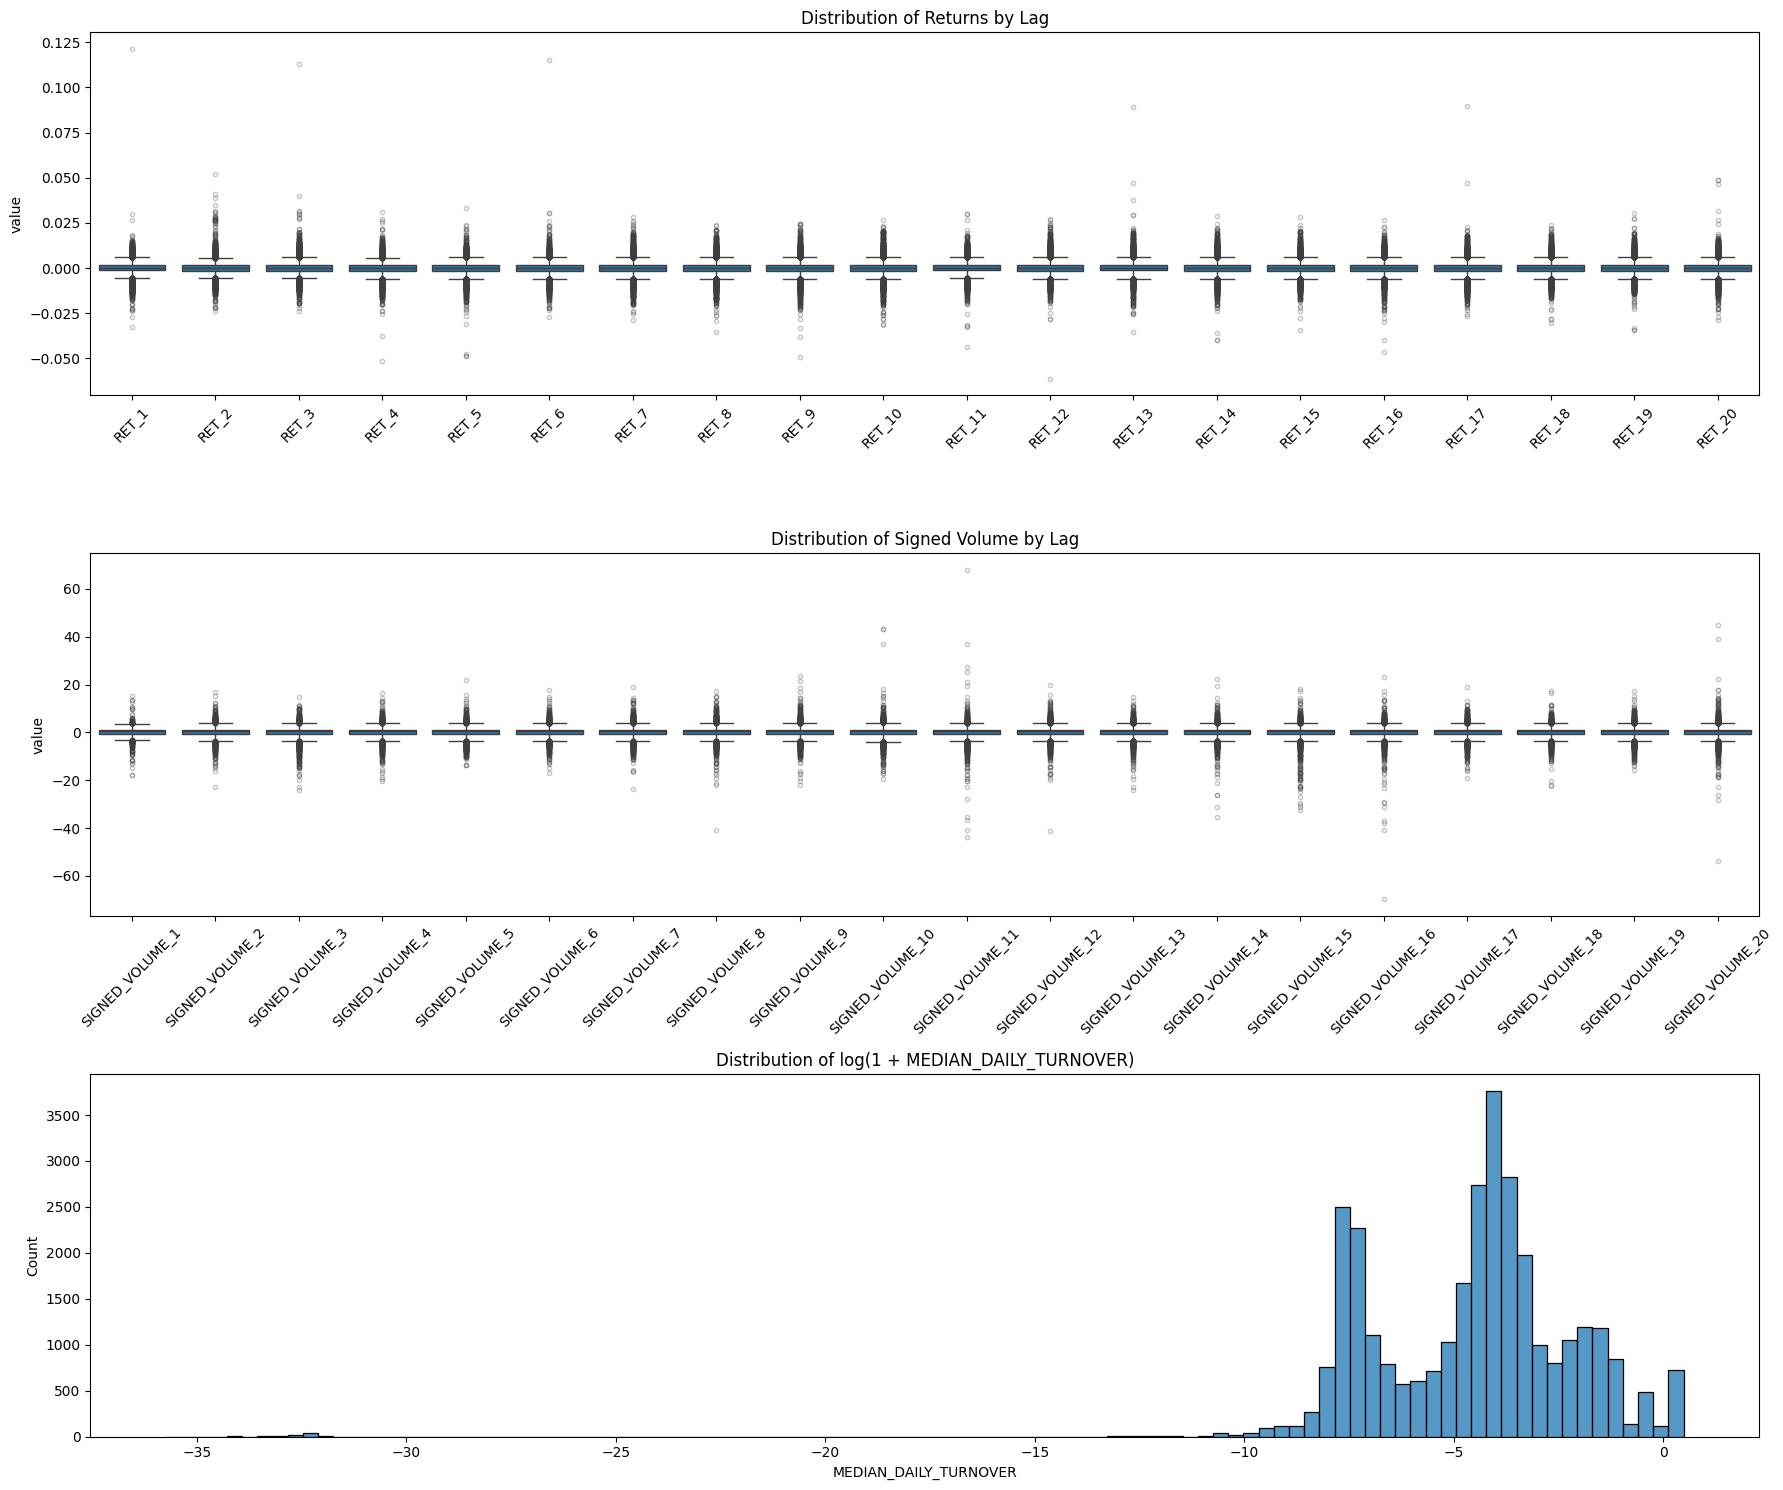

In [38]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

test_df[ret_cols].melt(var_name="lag", value_name="value").pipe( # long df pour seaborn 
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[0], 
                          order=ret_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[0].set_title("Distribution of Returns by Lag")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# Signed Volume
test_df[vol_cols].melt(var_name="lag", value_name="value").pipe(
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[1],
                          order=vol_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[1].set_title("Distribution of Signed Volume by Lag")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

# Turnover
sns.histplot(
    test_df["MEDIAN_DAILY_TURNOVER"].apply(np.log), 
    bins=100, ax=axes[2]
)
axes[2].set_title("Distribution of log(1 + MEDIAN_DAILY_TURNOVER)")

plt.tight_layout()
plt.show()

In [40]:
from scipy.stats import ks_2samp

all_feature_cols = ret_cols + vol_cols + ["MEDIAN_DAILY_TURNOVER"]

results = []
for col in all_feature_cols:
    train_vals = train_df[col].dropna()
    test_vals = test_df[col].dropna()
    stat, pvalue = ks_2samp(train_vals, test_vals)
    results.append({"feature": col, "ks_stat": stat, "pvalue": pvalue})

drift_df = pd.DataFrame(results).sort_values("ks_stat", ascending=False)
drift_df

,feature,ks_stat,pvalue
20,SIGNED_VOLUME_1,0.038178,5.727844e-10
40,MEDIAN_DAILY_TURNOVER,0.037774,1.624785e-37
29,SIGNED_VOLUME_10,0.034708,6.951792e-32
25,SIGNED_VOLUME_6,0.033135,4.206937e-29
26,SIGNED_VOLUME_7,0.032822,1.466102e-28
21,SIGNED_VOLUME_2,0.032432,6.731954e-28
12,RET_13,0.032006,3.541627e-27
22,SIGNED_VOLUME_3,0.031753,9.278375e-27
27,SIGNED_VOLUME_8,0.030886,2.439148e-25
24,SIGNED_VOLUME_5,0.030289,2.185951e-24


rmq: with 500k observation, ks test is too strong, so pval detects any tiny diff, but stat is small so ok, no practical drift 

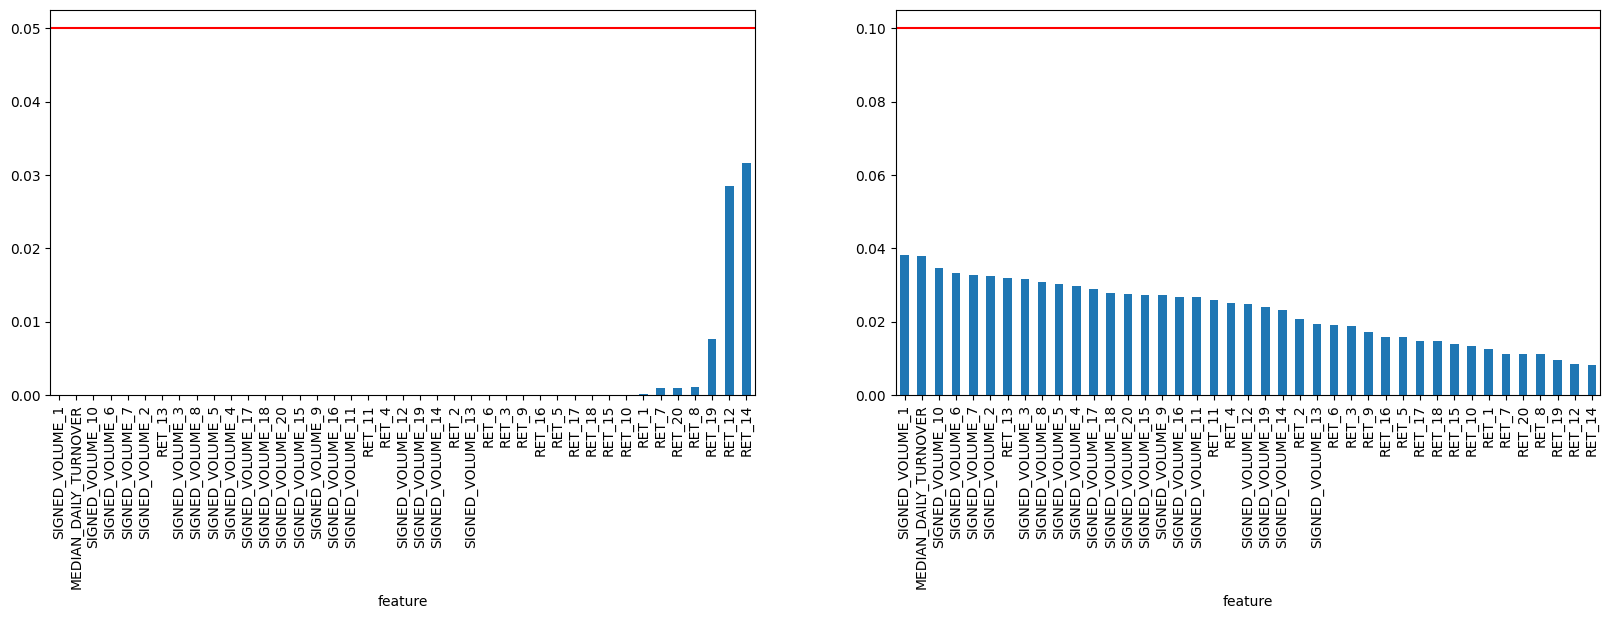

In [53]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
drift_df.set_index("feature").pvalue.plot(kind="bar", ax=ax[0])
ax[0].axhline(0.05, color="red")
drift_df.set_index("feature").ks_stat.plot(kind="bar", ax=ax[1])
ax[1].axhline(0.1, color="red")
plt.show()

MEDIAN_DAILY_TURNOVER => proxy of exposure to liquitidty, on average being long large caps is profitable 

RET_1, RET_7, RET_8, RET_9 => positive 
RET_3, RET_4 => negative 

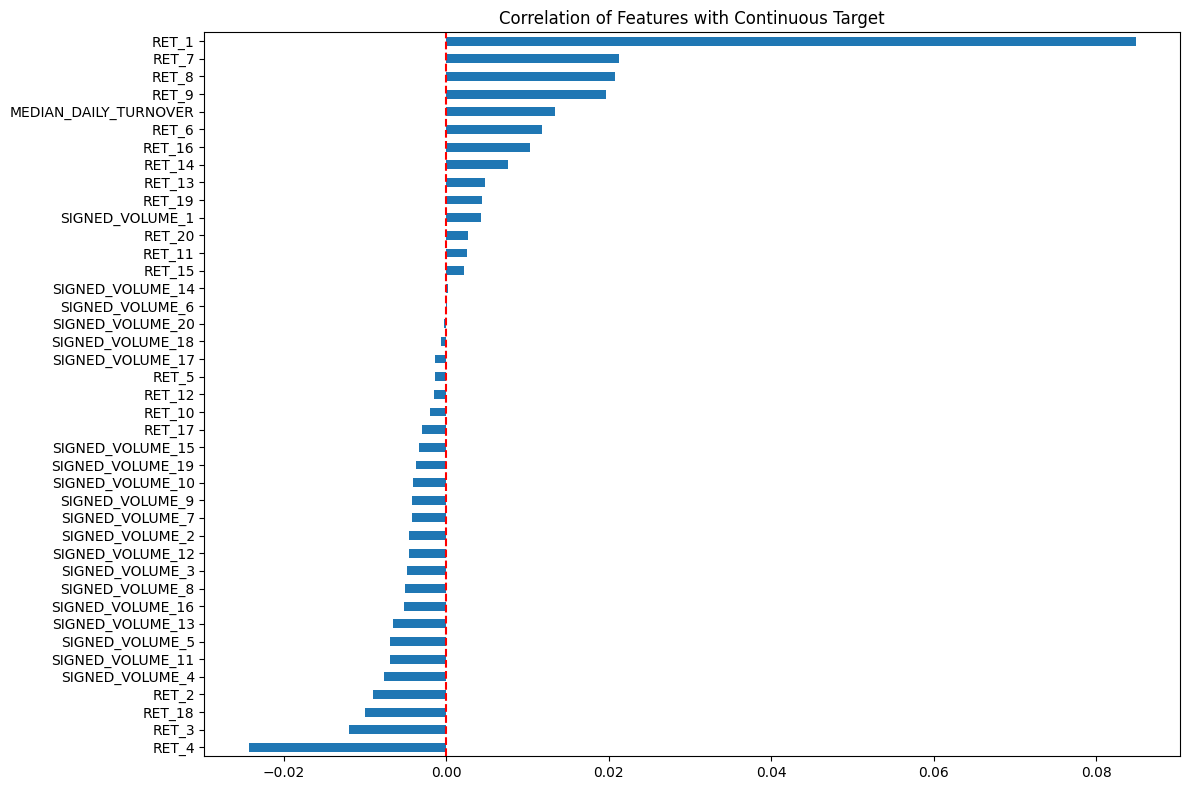

In [54]:
corr = train_df[all_feature_cols].corrwith(train_df["target"]).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
corr.plot(kind="barh", ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Correlation of Features with Continuous Target")
plt.tight_layout()
plt.show()

# Peu de signal ...

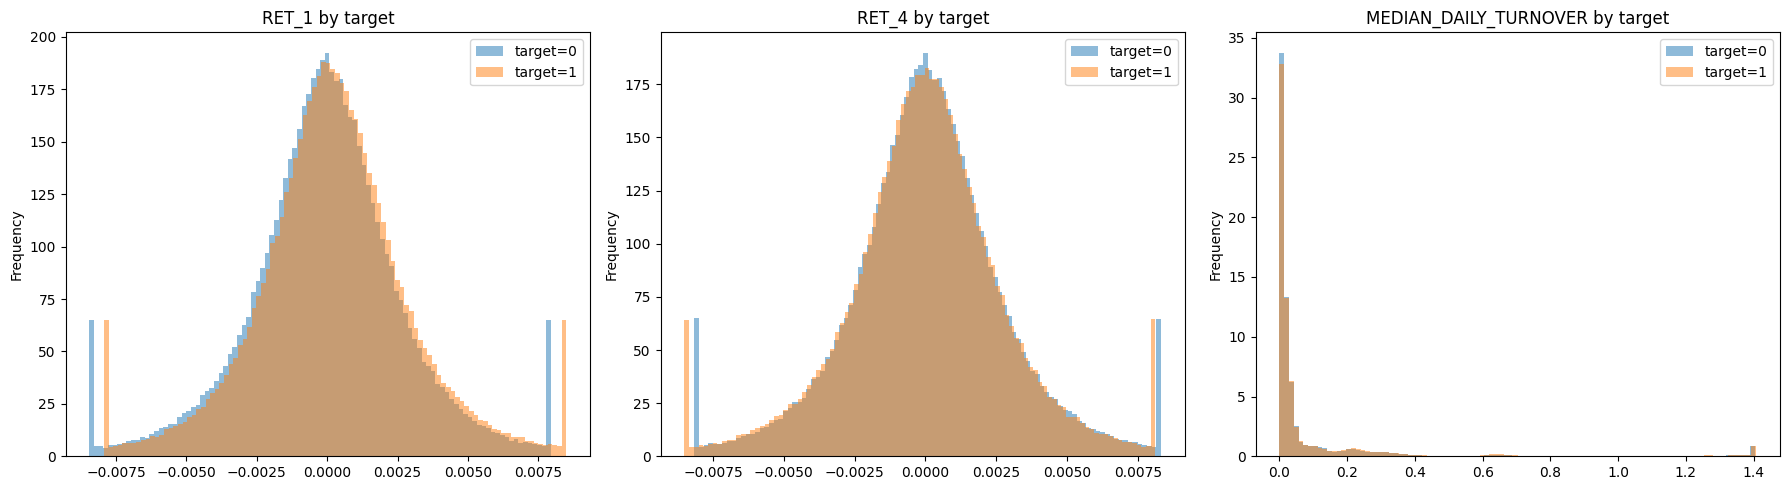

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["RET_1", "RET_4", "MEDIAN_DAILY_TURNOVER"]):
    for label, group in train_df.groupby("target_binarized")[col]:
        group.clip(*group.quantile([0.01, 0.99])).plot(
            kind="hist", bins=100, alpha=0.5, ax=ax, label=label, density=True
        )
    ax.set_title(f"{col} by target")
    ax.legend(["target=0", "target=1"])

plt.tight_layout()
plt.show()

/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_3245/2515529393.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_date = train_df.groupby("TS").apply(


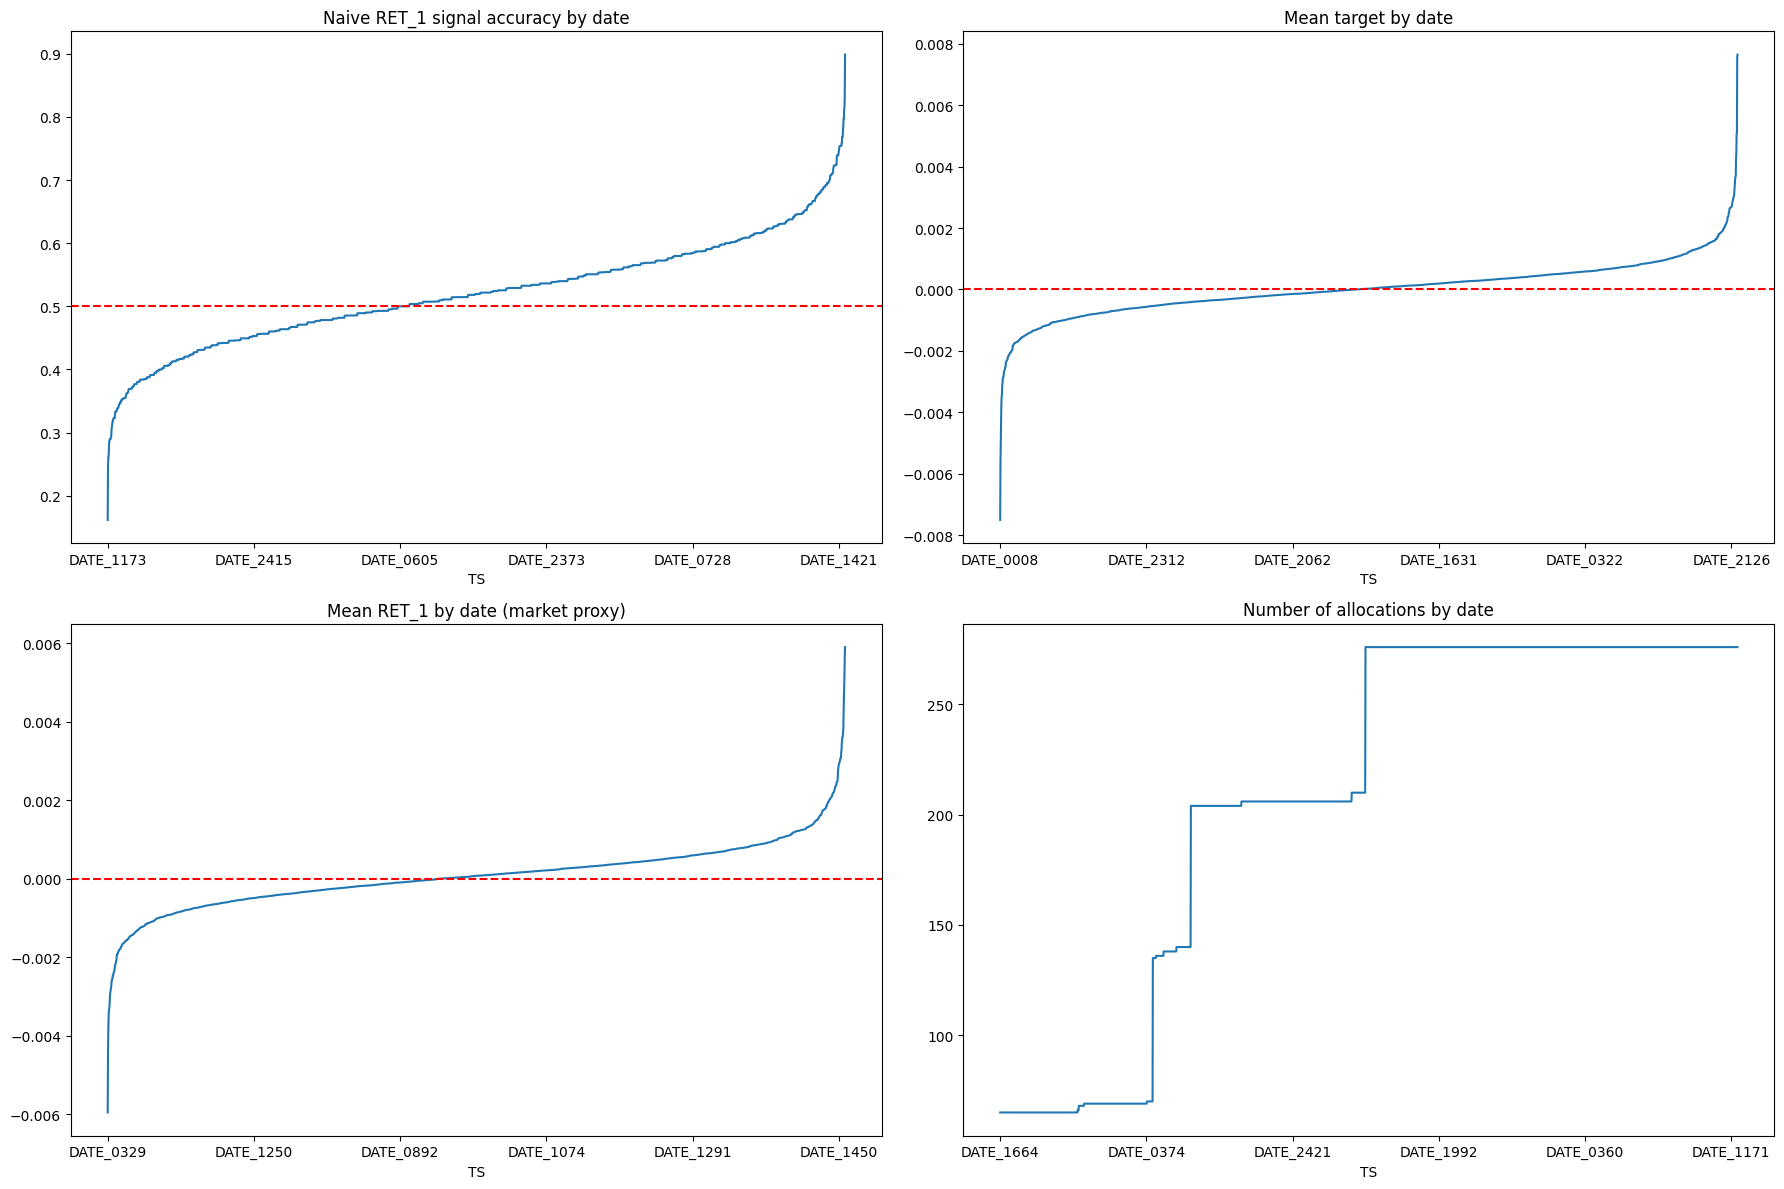

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy par date : signal debile ou on predit 1 si RET_1 > median(RET_1)
acc_by_date = train_df.groupby("TS").apply(
    lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
)
acc_by_date.sort_values().plot(ax=axes[0, 0])
axes[0, 0].axhline(0.5, color="red", linestyle="--")
axes[0, 0].set_title("Naive RET_1 signal accuracy by date")

# Mean target par date
train_df.groupby("TS")["target"].mean().sort_values().plot(ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Mean target by date")

# Mean RET_1 par date
train_df.groupby("TS")["RET_1"].mean().sort_values().plot(ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Mean RET_1 by date (market proxy)")

# Nb allocations par date
train_df.groupby("TS").size().sort_values().plot(ax=axes[1, 1])
axes[1, 1].set_title("Number of allocations by date")

plt.tight_layout()
plt.show()

# y a pas de truc facile pour predire les dates difficiles 

In [59]:
date_stats = pd.DataFrame({
    "mean_target": train_df.groupby("TS")["target"].mean(),
    "mean_ret1": train_df.groupby("TS")["RET_1"].mean(),
    "naive_accuracy": train_df.groupby("TS").apply(
        lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
    )
})

print(date_stats.corr())

                mean_target  mean_ret1  naive_accuracy
mean_target        1.000000   0.147206        0.021802
mean_ret1          0.147206   1.000000       -0.009344
naive_accuracy     0.021802  -0.009344        1.000000


/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_3245/2524210652.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "naive_accuracy": train_df.groupby("TS").apply(


In [58]:
date_stats["n_alloc"] = train_df.groupby("TS").size()
date_stats["ret1_std"] = train_df.groupby("TS")["RET_1"].std()
date_stats["ret1_dispersion"] = train_df.groupby("TS")["RET_1"].std() / train_df.groupby("TS")["RET_1"].mean().abs()

print(date_stats.corr()["naive_accuracy"].sort_values())

n_alloc           -0.107053
mean_ret1         -0.009344
mean_target        0.021802
ret1_dispersion    0.023961
ret1_std           0.081493
naive_accuracy     1.000000
Name: naive_accuracy, dtype: float64


In [62]:
# Sans neutralisation : long si RET_1 > 0
pred_raw = (train_df["RET_1"] > 0).astype(int)

# Avec neutralisation : long si RET_1 > médiane du jour
pred_neutralized = train_df.groupby("TS")["RET_1"].transform(
    lambda x: (x > x.median()).astype(int)
)

acc_raw = (pred_raw == train_df["target_binarized"]).groupby(train_df["TS"]).mean()
acc_neutralized = (pred_neutralized == train_df["target_binarized"]).groupby(train_df["TS"]).mean()

print(f"Raw accuracy: {acc_raw.mean():.4f} ± {acc_raw.std():.4f}")
print(f"Neutralized accuracy: {acc_neutralized.mean():.4f} ± {acc_neutralized.std():.4f}")

Raw accuracy: 0.5231 ± 0.0888
Neutralized accuracy: 0.5206 ± 0.0831


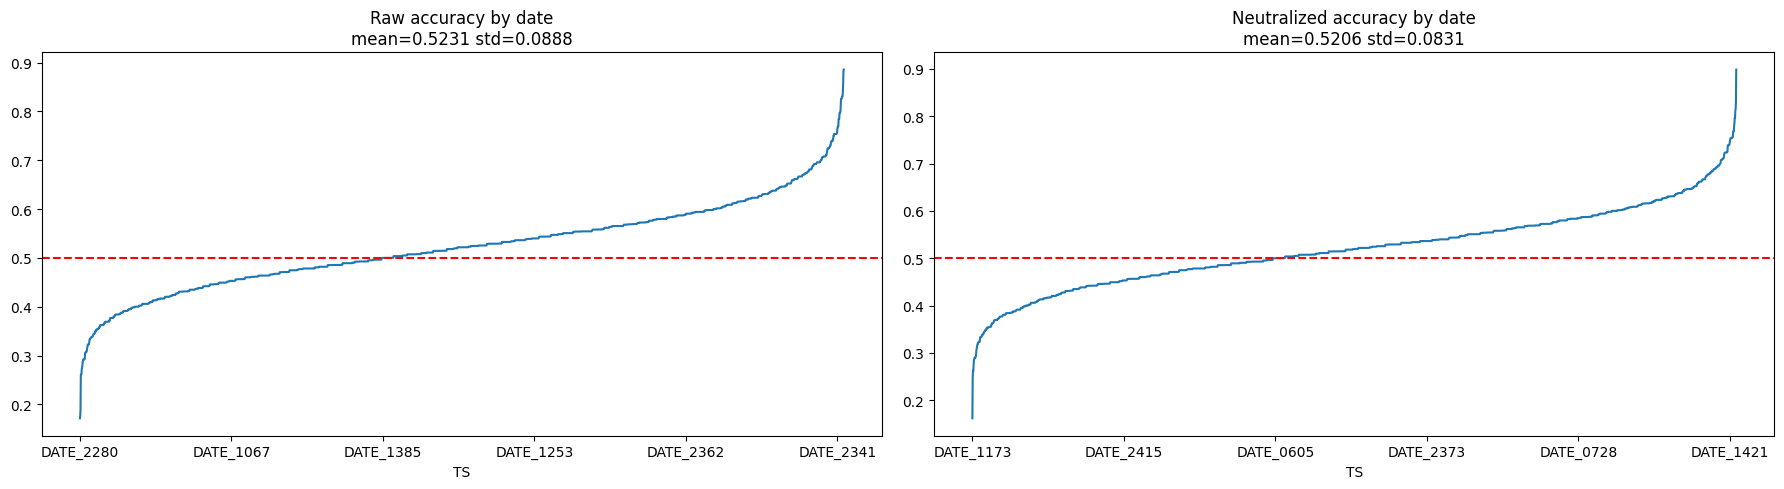

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

acc_raw.sort_values().plot(ax=axes[0])
axes[0].axhline(0.5, color="red", linestyle="--")
axes[0].set_title(f"Raw accuracy by date\nmean={acc_raw.mean():.4f} std={acc_raw.std():.4f}")

acc_neutralized.sort_values().plot(ax=axes[1])
axes[1].axhline(0.5, color="red", linestyle="--")
axes[1].set_title(f"Neutralized accuracy by date\nmean={acc_neutralized.mean():.4f} std={acc_neutralized.std():.4f}")

plt.tight_layout()
plt.show()

/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_3245/3687160295.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_date = train_df.groupby("ALLOCATION").apply(


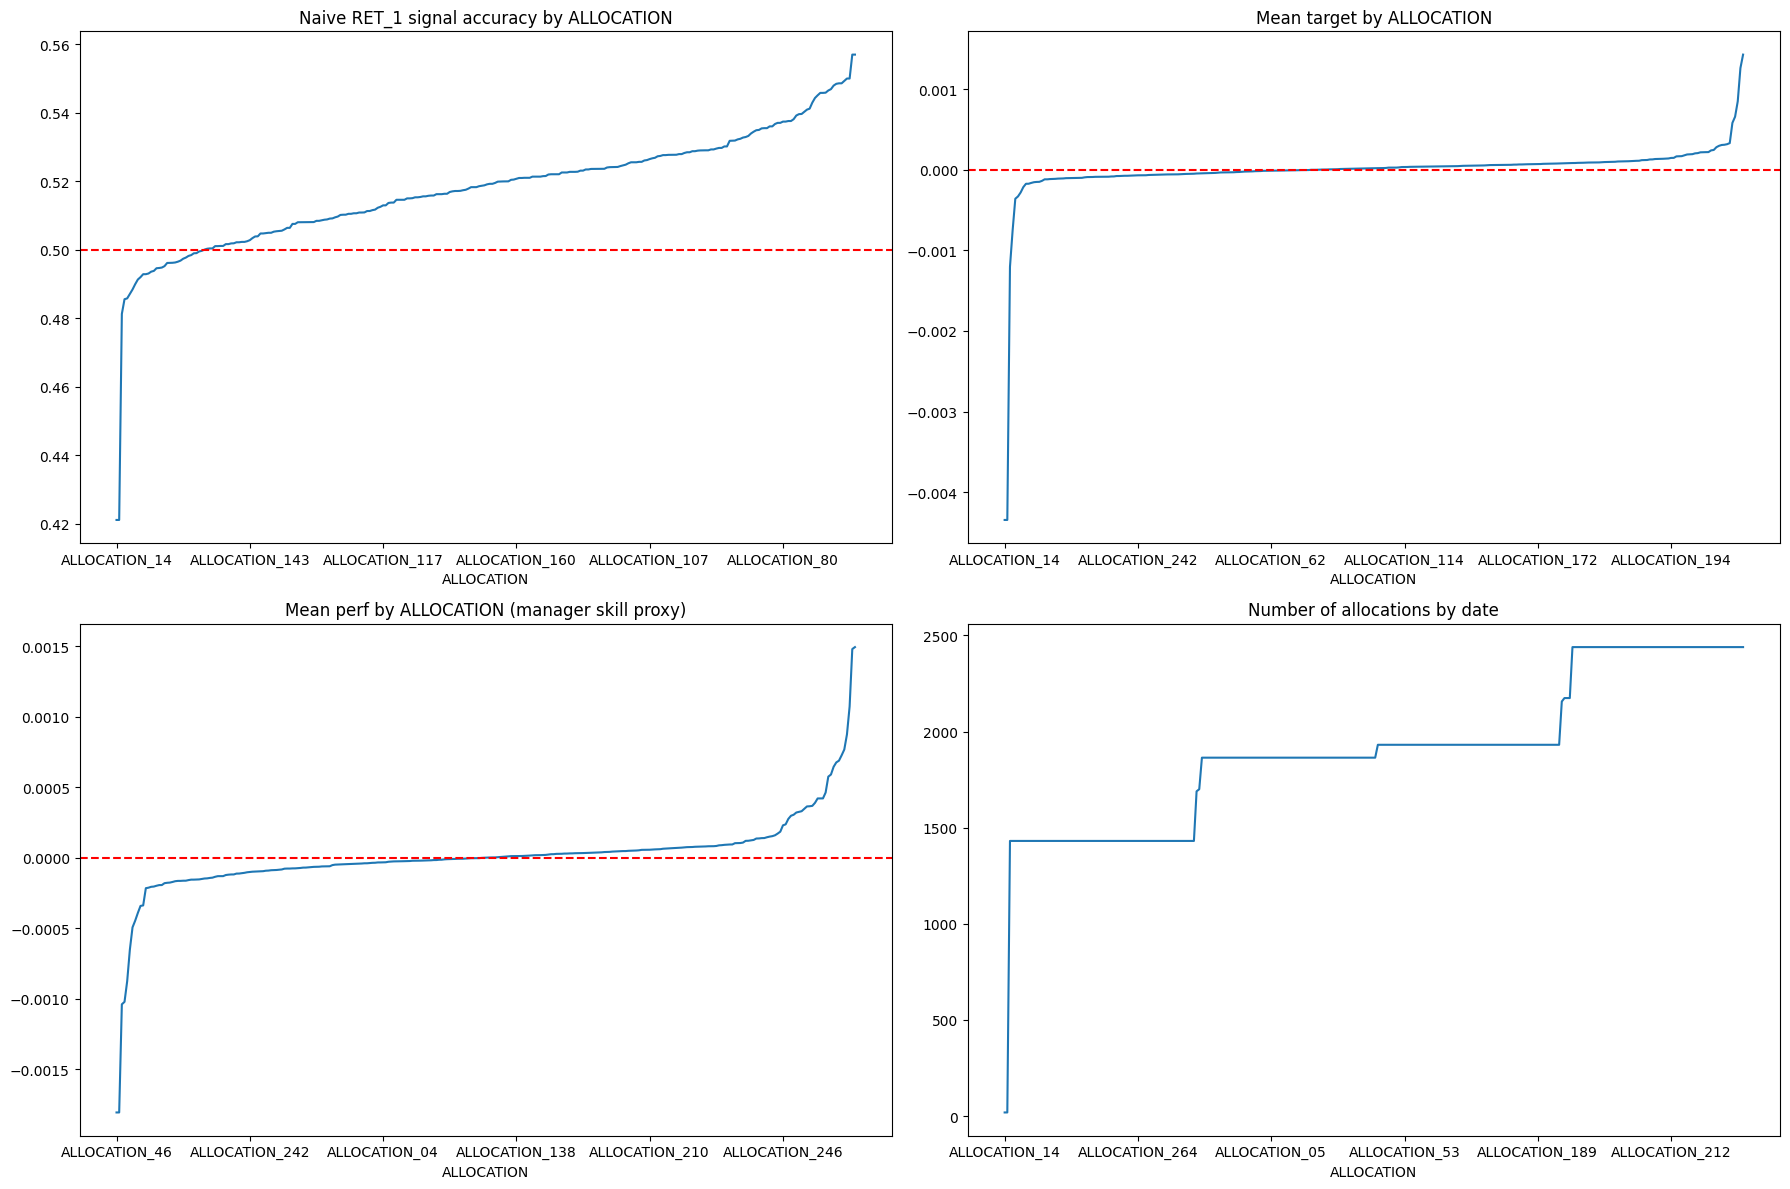

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy par date : signal debile ou on predit 1 si RET_1 > median(RET_1)
acc_by_date = train_df.groupby("ALLOCATION").apply(
    lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
)
acc_by_date.sort_values().plot(ax=axes[0, 0])
axes[0, 0].axhline(0.5, color="red", linestyle="--")
axes[0, 0].set_title("Naive RET_1 signal accuracy by ALLOCATION")

# Mean target par date
train_df.groupby("ALLOCATION")["target"].mean().sort_values().plot(ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Mean target by ALLOCATION")

# Mean RET_1 par date

train_df.assign(mean_perf=lambda df : df[ret_cols].mean(axis=1)).groupby("ALLOCATION")["mean_perf"].mean().sort_values().plot(ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Mean perf by ALLOCATION (manager skill proxy)")

# Nb date par alolocation
train_df.groupby("ALLOCATION").size().sort_values().plot(ax=axes[1, 1])
axes[1, 1].set_title("Number of allocations by date")

plt.tight_layout()
plt.show()

- RET_1 est le signal dominant
- Signal très faible partout — distributions quasi identiques entre classes
- Pas de drift train/test
- Dates difficiles existent et ne s'expliquent pas facilement
- La neutralisation stabilise légèrement mais ne résout pas le problème fondamental (et encore)

In [67]:
alloc_stats = pd.DataFrame({
    "mean_target": train_df.groupby("ALLOCATION")["target"].mean(),
    "mean_ret1": train_df.groupby("ALLOCATION")["RET_1"].mean(),
    "naive_accuracy": acc_by_date
})
print(alloc_stats.corr())

                mean_target  mean_ret1  naive_accuracy
mean_target        1.000000   0.962932        0.393745
mean_ret1          0.962932   1.000000        0.443001
naive_accuracy     0.393745   0.443001        1.000000


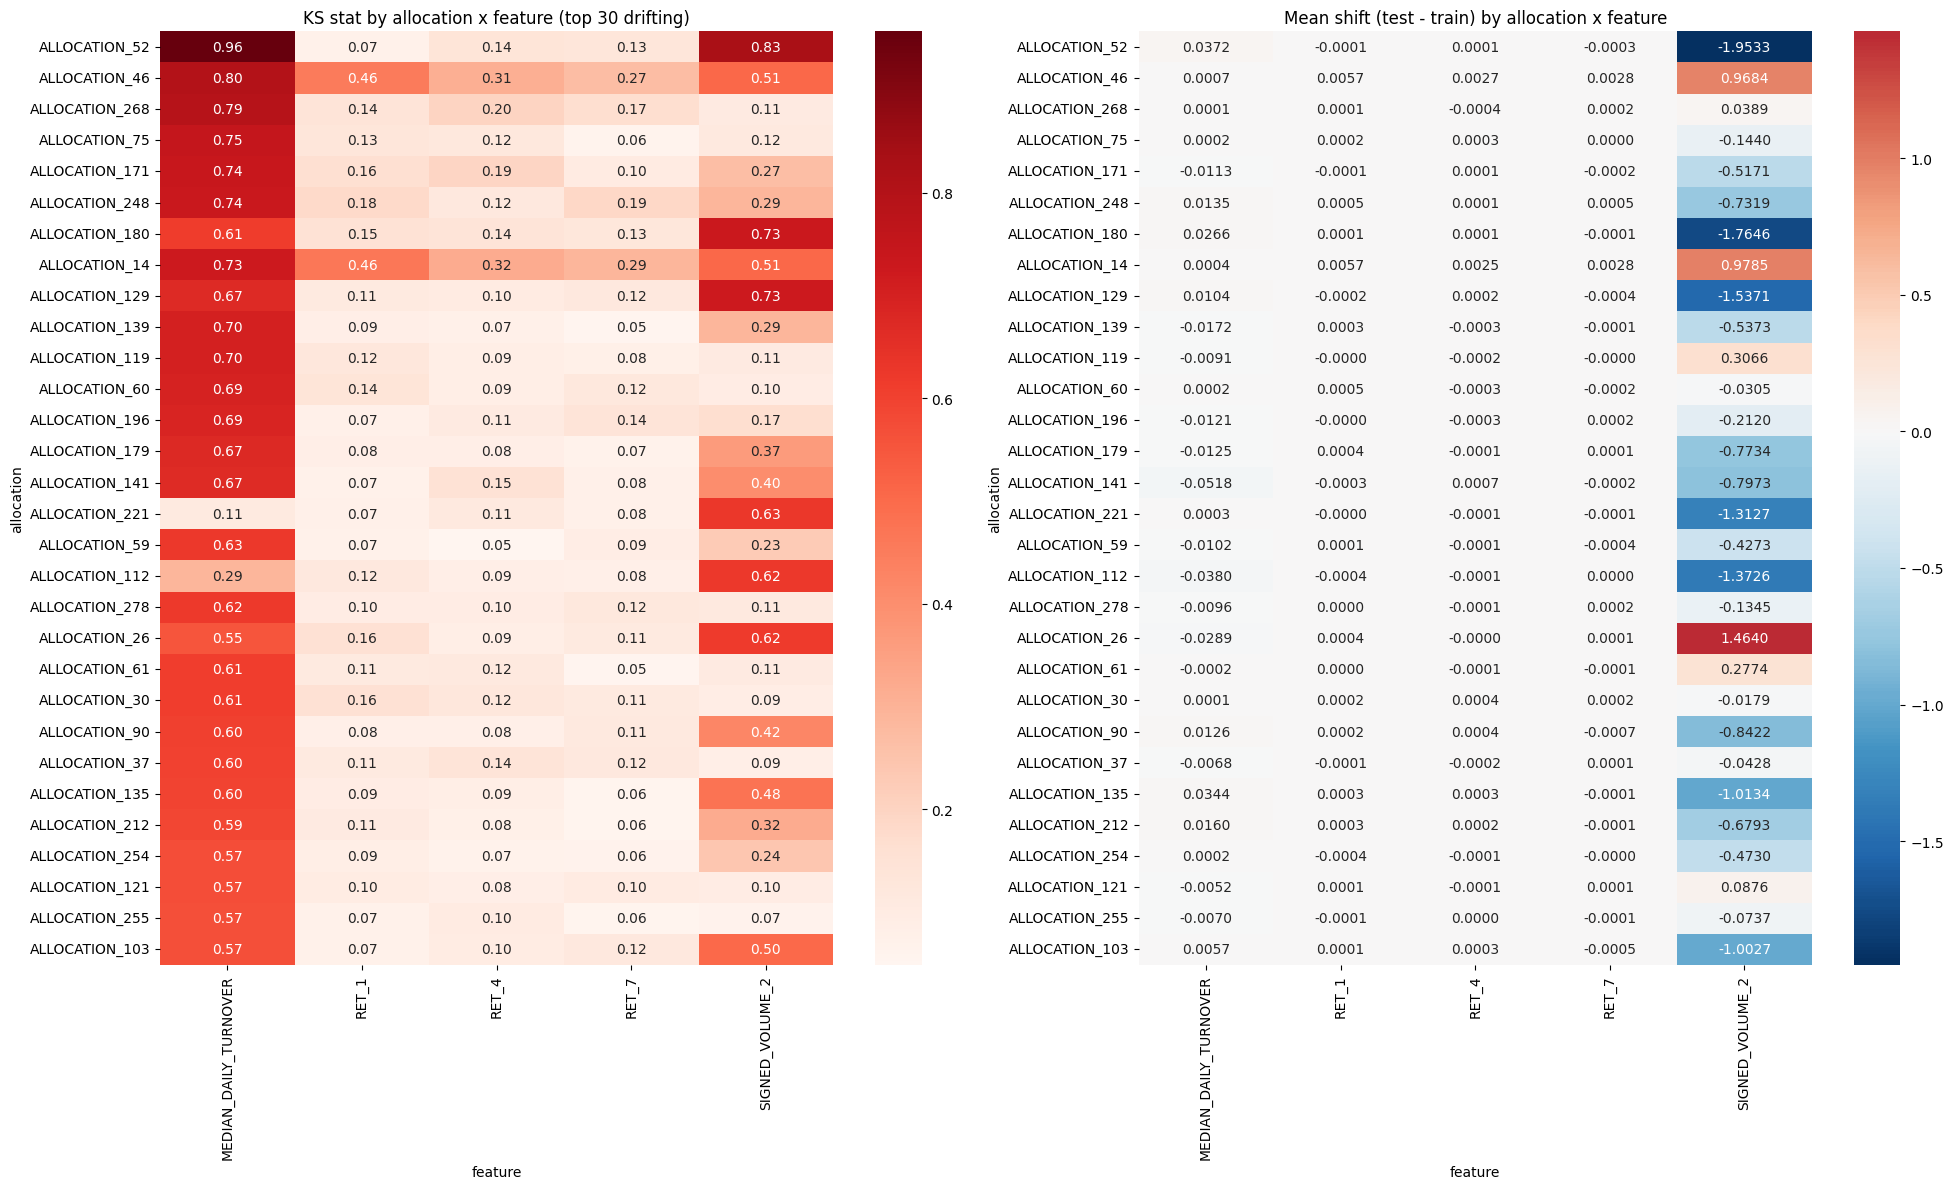

In [82]:
features_to_check = ["RET_1", "RET_4", "RET_7", "SIGNED_VOLUME_2", "MEDIAN_DAILY_TURNOVER"]

all_drift = []
for feat in features_to_check:
    for alloc in train_df["ALLOCATION"].unique():
        train_vals = train_df[train_df["ALLOCATION"] == alloc][feat].dropna()
        test_vals = test_df[test_df["ALLOCATION"] == alloc][feat].dropna()
        if len(train_vals) == 0 or len(test_vals) == 0:
            continue
        stat, pvalue = ks_2samp(train_vals, test_vals)
        all_drift.append({
            "feature": feat,
            "allocation": alloc,
            "ks_stat": stat,
            "mean_shift": test_vals.mean() - train_vals.mean()
        })

drift_df = pd.DataFrame(all_drift)

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Heatmap KS stat
ks_pivot = drift_df.pivot(index="allocation", columns="feature", values="ks_stat")
top_allocs = ks_pivot.max(axis=1).sort_values(ascending=False).head(30).index
sns.heatmap(
    ks_pivot.loc[top_allocs],
    annot=True, fmt=".2f", cmap="Reds",
    ax=axes[0]
)
axes[0].set_title("KS stat by allocation x feature (top 30 drifting)")

# Heatmap mean shift
shift_pivot = drift_df.pivot(index="allocation", columns="feature", values="mean_shift")
sns.heatmap(
    shift_pivot.loc[top_allocs],
    annot=True, fmt=".4f", cmap="RdBu_r", center=0,
    ax=axes[1]
)
axes[1].set_title("Mean shift (test - train) by allocation x feature")

plt.tight_layout()
plt.show()